# TIỀN XỬ LÝ DỮ LIỆU

Notebook này thực hiện toàn bộ quá trình tiền xử lý dữ liệu bao gồm:

1. Đọc dữ liệu gốc.
2. Khảo sát và đánh giá chất lượng dữ liệu.
3. Làm sạch dữ liệu.
4. Xây dựng các thuộc tính mới (Feature Engineering).
5. Xuất bộ dữ liệu sạch phục vụ cho bước phân tích khám phá dữ liệu và xây dựng Dashboard.

## 1. Đọc dữ liệu gốc

In [1]:
# Tắt các cảnh báo không cần thiết
import warnings
warnings.filterwarnings("ignore")

# Xử lý biểu thức chính quy
import re

# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
from pathlib import Path

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị đầy đủ các cột
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Thiết lập giao diện biểu đồ
plt.style.use("ggplot")

In [2]:
# Đường dẫn đến dữ liệu gốc
DATA_PATH = Path("../raw/house_price.csv")

# Đọc dữ liệu
df = pd.read_csv(DATA_PATH)


## 2. Khảo sát dữ liệu

Khảo sát tổng quan bộ dữ liệu nhằm đánh giá chất lượng dữ liệu trước khi thực hiện tiền xử lý.

### 2.1 Tổng quan bộ dữ liệu

In [3]:
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột : {df.shape[1]}")

# Hiển thị 5 dòng đầu tiên
df.head()

Số dòng: 30,229
Số cột : 12


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ Chí Minh",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


### 2.2 Danh sách các thuộc tính

In [4]:
pd.DataFrame({
    "Tên thuộc tính": df.columns
})

,Tên thuộc tính
0,Address
1,Area
2,Frontage
3,Access Road
4,House direction
5,Balcony direction
6,Floors
7,Bedrooms
8,Bathrooms
9,Legal status


### 2.3 Kiểm tra kiểu dữ liệu

In [5]:
# Thông tin tổng quan của bộ dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 5.4 MB


In [6]:
# Thống kê số lượng từng kiểu dữ liệu
df.dtypes.value_counts()

float64    7
str        5
Name: count, dtype: int64

### 2.4 Kiểm tra giá trị khuyết

In [7]:
# Thống kê số lượng và tỷ lệ giá trị thiếu
missing = pd.DataFrame({
    "Số lượng thiếu": df.isnull().sum(),
    "Tỷ lệ (%)": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Số lượng thiếu"] > 0]

missing.sort_values(
    by="Tỷ lệ (%)",
    ascending=False
)

,Số lượng thiếu,Tỷ lệ (%)
Balcony direction,24983,82.65
House direction,21239,70.26
Furniture state,14119,46.71
Access Road,13297,43.99
Frontage,11564,38.25
Bathrooms,7074,23.40
Bedrooms,5162,17.08
Legal status,4506,14.91
Floors,3603,11.92


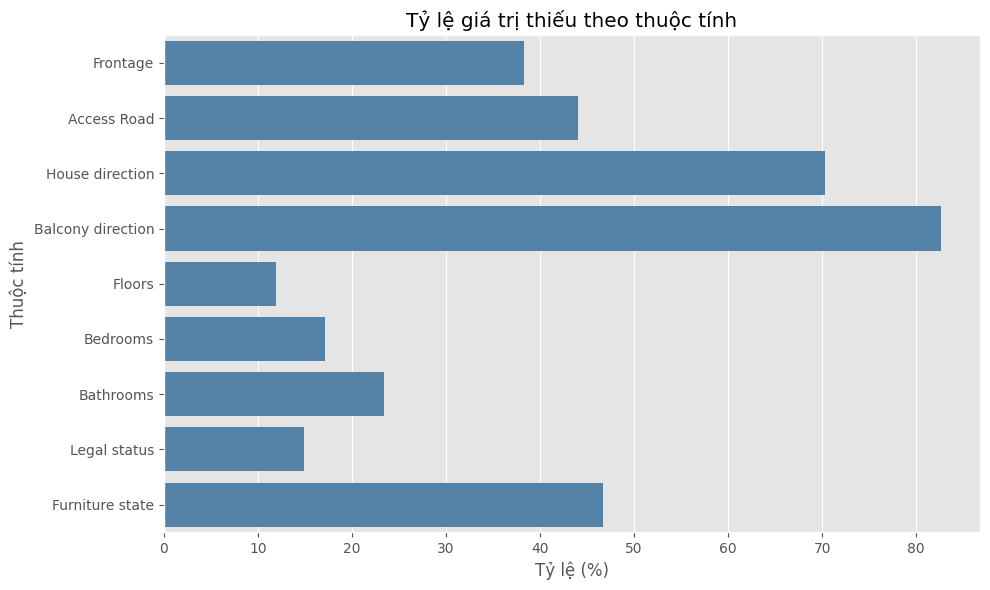

In [8]:
# Trực quan hóa tỷ lệ giá trị thiếu
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing.reset_index(),
    x="Tỷ lệ (%)",
    y="index",
    color="steelblue"
)

plt.title("Tỷ lệ giá trị thiếu theo thuộc tính")
plt.xlabel("Tỷ lệ (%)")
plt.ylabel("Thuộc tính")

plt.tight_layout()
plt.show()

### 2.5 Kiểm tra dữ liệu trùng lặp

In [9]:
duplicate_count = df.duplicated().sum()

print(f"Số dòng bị trùng lặp: {duplicate_count}")

# Hiển thị các dòng bị trùng (nếu có)
if duplicate_count > 0:
    display(df[df.duplicated()].head())
else:
    print("Không phát hiện dữ liệu trùng lặp.")

Số dòng bị trùng lặp: 0
Không phát hiện dữ liệu trùng lặp.


### 2.6 Kiểm tra giá trị của các thuộc tính

Thống kê số lượng giá trị khác nhau của từng thuộc tính và kiểm tra các thuộc tính dạng phân loại để phát hiện các giá trị chưa đồng nhất.

In [10]:
unique_summary = pd.DataFrame({
    "Thuộc tính": df.columns,
    "Số giá trị khác nhau": df.nunique().values
})

unique_summary = unique_summary.sort_values(
    by="Số giá trị khác nhau",
    ascending=False
).reset_index(drop=True)

unique_summary

,Thuộc tính,Số giá trị khác nhau
0,Address,10265
1,Area,1512
2,Price,687
3,Frontage,407
4,Access Road,140
5,Floors,10
6,Bathrooms,9
7,Bedrooms,9
8,House direction,8
9,Balcony direction,8


In [11]:
#In ra giá trị và số lượng của các thuộc tính dạng categorical, để tìm ra phương án chuẩn hóa ở phần sau
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 80)
    print(df[col].value_counts(dropna=False))
    print()

Address
Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên                    187
Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên                     129
Đường Trương Định, Phường Trương Định, Hai Bà Trưng, Hà Nội                                     84
Đường Ngọc Thụy, Phường Ngọc Thụy, Long Biên, Hà Nội                                            77
Đường Minh Khai, Phường Minh Khai, Hai Bà Trưng, Hà Nội                                         74
                                                                                              ... 
Dự án Center Park, Đường Hoàng Quốc Việt, Phường An Đông, Huế, Thừa Thiên Huế                    1
Dự án The Crown - Vinhomes Ocean Park 3, Đường Vân Giang, Xã Nghĩa Trụ, Văn Giang, Hưng Yên      1
Đường 10, Phường Long Bình, Quận 9, Hồ Chí Minh                                                  1
Đường Ngô Thì Sĩ, Phường Mỹ An, Ngũ Hành Sơn, Đà Nẵng.                                           1
Đư

### 2.7 Thống kê mô tả

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,30229.0,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,7.853800,7.451313,1.0,4.0,6.0,10.0,85.0
Floors,26626.0,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,3.511030,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Price,30229.0,5.872078,2.211877,1.0,4.2,5.9,7.5,11.5


### 2.8 Phát hiện giá trị ngoại lai

In [13]:
# Lấy danh sách các thuộc tính số
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms',
       'Price'],
      dtype='str')

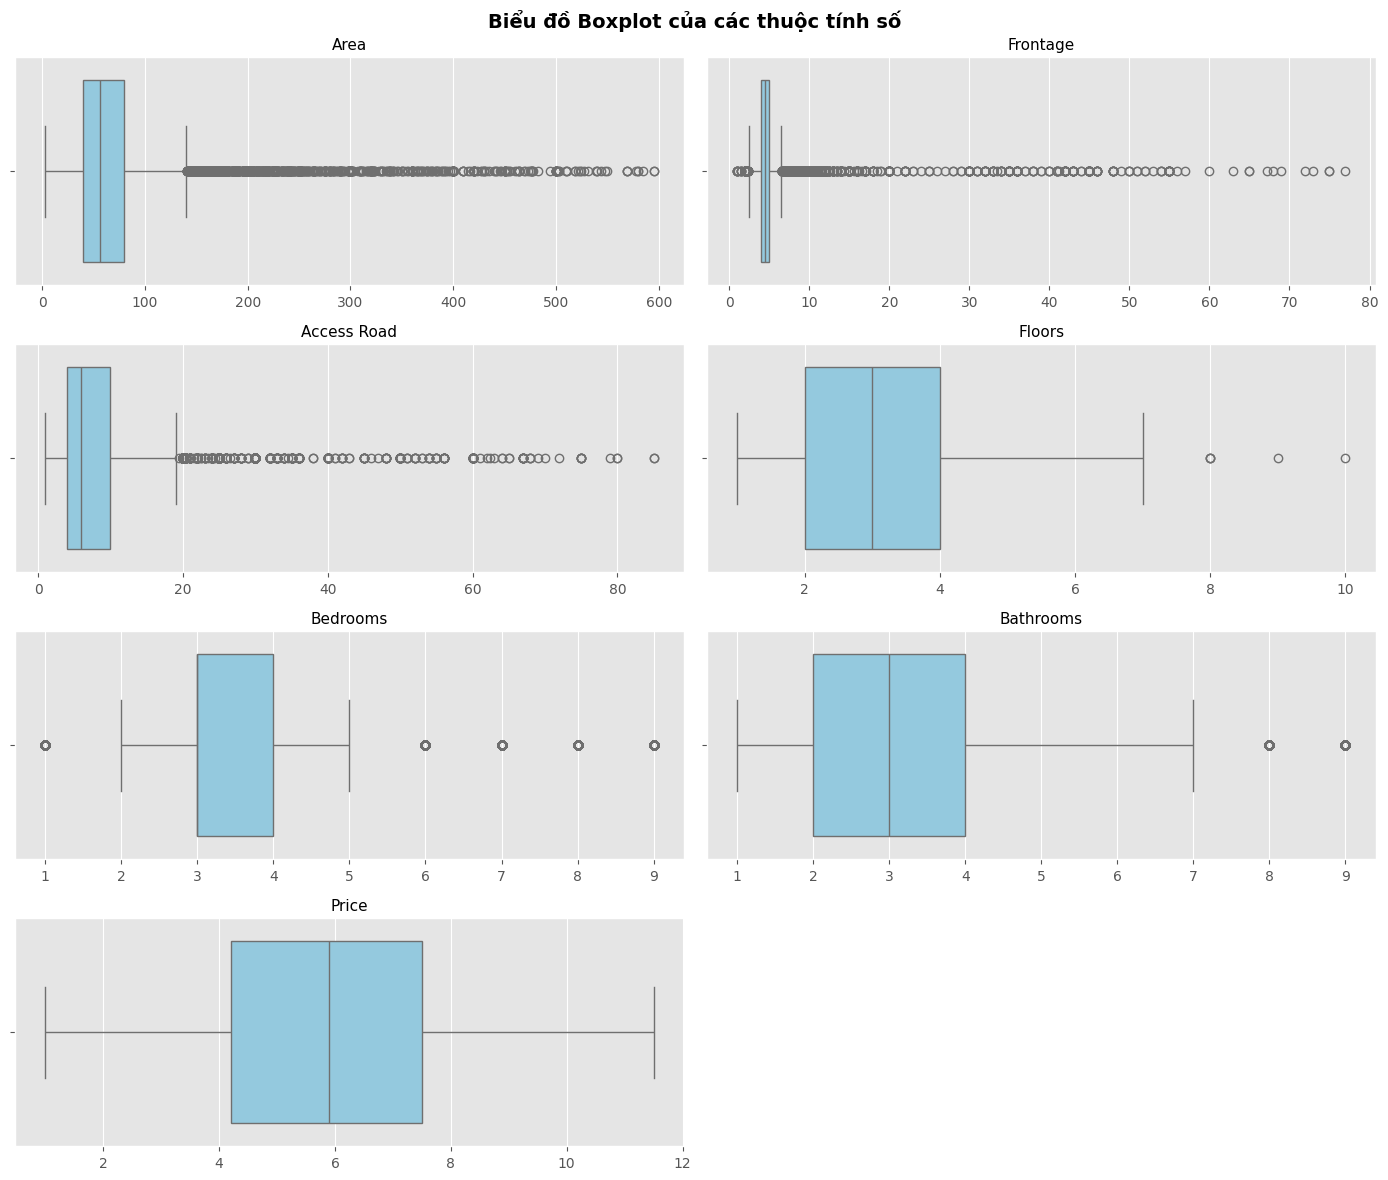

In [14]:
# Vẽ Boxplot cho các thuộc tính số theo dạng lưới 2 cột

numeric_cols = df.select_dtypes(include=np.number).columns

n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

# Chuyển axes thành mảng 1 chiều để dễ duyệt
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

# Xóa các subplot thừa (nếu số cột lẻ)
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Biểu đồ Boxplot của các thuộc tính số", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()

## 3. Tiền xử lý dữ liệu

### 3.1 Xử lý dữ liệu trùng lắp

In [15]:
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Đã loại bỏ {duplicate_count} dòng dữ liệu trùng lặp.")
else:
    print("Không phát hiện dữ liệu trùng lặp.")

Không phát hiện dữ liệu trùng lặp.


### 3.2 Xử lý giá trị khuyết
- Đối với các thuộc tính dạng phân loại, các giá trị thiếu được thay thế bằng **"Không xác định"**.

- Đối với các thuộc tính dạng số, các giá trị thiếu được thay thế bằng **trung vị (Median)** nhằm giảm ảnh hưởng của các giá trị ngoại lai.

In [16]:
# Các cột phân loại
categorical_fill = {
    "House direction": "Không xác định",
    "Balcony direction": "Không xác định",
    "Legal status": "Không xác định",
    "Furniture state": "Không xác định"
}

# Thay thế giá trị thiếu của các cột phân loại
df.fillna(categorical_fill, inplace=True)

print("Đã xử lý giá trị thiếu cho các cột phân loại.")

Đã xử lý giá trị thiếu cho các cột phân loại.


In [17]:
# Các cột số cần xử lý giá trị thiếu
numeric_fill = [
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms"
]

# Thay thế giá trị thiếu bằng trung vị của từng cột
for col in numeric_fill:
    df[col] = df[col].fillna(df[col].median())

print("Đã xử lý giá trị thiếu cho các cột số.")

Đã xử lý giá trị thiếu cho các cột số.


### 3.3 Chuẩn hóa dữ liệu
Thay đổi chuyển giá trị của các cột phân loại từ tiếng Anh thành tiếng Việt. 

In [18]:
# Chuẩn hóa tình trạng pháp lý
legal_mapping = {
    "Have certificate": "Đã có sổ",
    "Sale contract": "Hợp đồng mua bán"
}

df["Legal status"] = df["Legal status"].replace(legal_mapping)

print("Đã chuẩn hóa cột 'Legal status'.")

Đã chuẩn hóa cột 'Legal status'.


In [19]:
# Chuẩn hóa tình trạng nội thất
furniture_mapping = {
    "Full": "Đầy đủ",
    "Basic": "Cơ bản"
}

df["Furniture state"] = df["Furniture state"].replace(furniture_mapping)

print("Đã chuẩn hóa cột 'Furniture state'.")

Đã chuẩn hóa cột 'Furniture state'.


## 4. Xây dựng các thuộc tính mới (Feauture Engineering)

### 4.1 Tách thông tin địa chỉ

In [20]:
# Tách địa chỉ thành danh sách
address_parts = df["Address"].str.split(",")

# Tỉnh/Thành phố
df["Province"] = address_parts.str[-1].str.strip().str.rstrip(".")

# Quận/Huyện
df["District"] = address_parts.str[-2].str.strip()

# Phường/Xã
df["Ward"] = address_parts.str[-3].str.strip()

# Phần còn lại của địa chỉ
df["Detail"] = address_parts.apply(
    lambda x: ", ".join([part.strip() for part in x[:-3]]) if len(x) > 3 else np.nan
)

print("Đã tách địa chỉ thành các cột 'Province', 'District', 'Ward' và 'Detail'.")

Đã tách địa chỉ thành các cột 'Province', 'District', 'Ward' và 'Detail'.


### 4.2 Tạo thuộc tính mới

In [21]:
# Giá trên mỗi mét vuông
df["Price_per_m2"] = (df["Price"] / df["Area"]).round(2)

print("Đã tạo thuộc tính 'Price_per_m2'.")

Đã tạo thuộc tính 'Price_per_m2'.


### 4.4 Phân nhóm dữ liệu
Trước khi phân nhóm, tiến hành khảo sát các mốc phân vị của từng thuộc tính nhằm xác định các khoảng giá trị đại diện cho phân bố dữ liệu. Các mốc này sau đó được làm tròn thành các ngưỡng dễ hiểu để sử dụng trong Dashboard.

In [22]:
# Các mốc phân vị của diện tích
area_quantiles = df["Area"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

area_quantiles

0.0      3.1
0.2     38.0
0.4     50.0
0.6     64.0
0.8     90.0
1.0    595.0
Name: Area, dtype: float64

In [23]:
area_bins = [0, 30, 50, 70, 90, np.inf]

area_labels = [
    "<30 m²",
    "30-50 m²",
    "50-70 m²",
    "70-90 m²",
    ">90 m²"
]

df["Area_Group"] = pd.cut(
    df["Area"],
    bins=area_bins,
    labels=area_labels,
    include_lowest=True
)

print("Đã tạo thuộc tính 'Area_Group'.")

Đã tạo thuộc tính 'Area_Group'.


In [24]:
# Các mốc phân vị của giá bán
price_quantiles = df["Price"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

price_quantiles

0.0     1.00
0.2     3.80
0.4     5.25
0.6     6.50
0.8     7.98
1.0    11.50
Name: Price, dtype: float64

In [25]:
price_bins = [0, 4, 6, 8, 10, np.inf]

price_labels = [
    "<4 tỷ",
    "4-6 tỷ",
    "6-8 tỷ",
    "8-10 tỷ",
    ">10 tỷ"
]

df["Price_Segment"] = pd.cut(
    df["Price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

print("Đã tạo thuộc tính 'Price_Segment'.")

Đã tạo thuộc tính 'Price_Segment'.


In [26]:
# Kiểm tra thông tin dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            30229 non-null  str     
 1   Area               30229 non-null  float64 
 2   Frontage           30229 non-null  float64 
 3   Access Road        30229 non-null  float64 
 4   House direction    30229 non-null  str     
 5   Balcony direction  30229 non-null  str     
 6   Floors             30229 non-null  float64 
 7   Bedrooms           30229 non-null  float64 
 8   Bathrooms          30229 non-null  float64 
 9   Legal status       30229 non-null  str     
 10  Furniture state    30229 non-null  str     
 11  Price              30229 non-null  float64 
 12  Province           30229 non-null  object  
 13  District           30226 non-null  object  
 14  Ward               30224 non-null  object  
 15  Detail             27395 non-null  str     
 16  Price_per_m2   

### 4.5 Chuẩn hóa lại dữ liệu sau Feature Engineering

In [27]:
df['Province'].unique()

array(['Hưng Yên', 'Hồ Chí Minh', 'Hà Nội', 'Quảng Ninh', 'Bình Dương',
       'Phú Thọ', 'Hải Dương', 'Long An', 'Kiên Giang', 'Bình Thuận',
       'Hải Phòng', 'Hà Nam', 'Bà Rịa Vũng Tàu', 'Hồ Chí Minh giá 2tỷ380',
       'Đắk Lắk', 'Bắc Ninh', 'Thanh Hóa', 'Khánh Hòa', 'Đà Nẵng',
       'Thái Nguyên', 'Quảng Trị', 'Đồng Nai', 'Tuyên Quang',
       'Ninh Thuận', 'Nghệ An', 'Cần Thơ', 'Thái Bình', 'Bắc Giang',
       'Lâm Đồng', 'Trà Vinh', 'Bình Phước', 'Quảng Nam', 'Hòa Bình',
       'Thừa Thiên Huế', 'Sơn La', 'Bình Định', 'Vĩnh Phúc', 'Tây Ninh',
       'Tiền Giang', 'Hà Tĩnh', 'Lạng Sơn', 'Hà Nội', 'Lào Cai',
       'Điện Biên', 'Gia Lai', 'Đường số 11', 'Phú Yên', 'Bến Tre',
       'Quận Bình Thạnh', 'An Giang', 'TPHCM', 'TpHCM',
       'Phòng công chứng Nguyễn Thị Thành', 'Quảng Ngãi', 'Hà Giang',
       'HN', 'Nam Định', 'Sóc Trăng', 'Ninh Bình', 'Yên Bái', 'Cà Mau',
       'Bạc Liêu',
       'Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt',


Nhận thấy tên các tỉnh thành được viết dưới nhiều dạng, do đó cần tiền hành chuẩn hóa:

In [28]:
# Chuẩn hóa các tên được viết tắt 
province_mapping = {
    "TPHCM": "Hồ Chí Minh",
    "TpHCM": "Hồ Chí Minh",
    "TP. HCM": "Hồ Chí Minh",
    "TP Hồ Chí Minh": "Hồ Chí Minh",
    "Hồ Chí Mính": "Hồ Chí Minh",
    "HN": "Hà Nội",
    "Hà Nội": "Hà Nội",
}

df["Province"] = df["Province"].replace(province_mapping)

In [29]:
# Giữ lại tên tỉnh nếu phía sau có thêm mô tả

df.loc[
    df["Province"].str.contains("Hồ Chí Minh", na=False),
    "Province"
] = "Hồ Chí Minh"

df.loc[
    df["Province"].str.contains("Bình Dương", na=False),
    "Province"
] = "Bình Dương"

df.loc[
    df["Province"].str.contains("Quảng Ninh", na=False),
    "Province"
] = "Quảng Ninh"

In [30]:
# Một số giá trị thực chất là quận/thành phố trực thuộc

province_mapping = {
    "Quận Bình Thạnh": "Hồ Chí Minh",
    "Quận 8": "Hồ Chí Minh",
    "Quận Nam Từ Liêm": "Hà Nội",
    "TP. Cam Ranh": "Khánh Hòa"
}

df["Province"] = df["Province"].replace(province_mapping)

In [31]:
# Các giá trị không phải tên tỉnh/thành

invalid_province = [
    "Đường số 11",
    "giá 6ty",
    "Phòng công chứng Nguyễn Thị Thành",
    "Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt",
    "Hồ Chí Minh giá 2tỷ380"
]

df.loc[
    df["Province"].isin(invalid_province),
    "Province"
] = "Không xác định"

In [32]:
df['Province'].unique()

array(['Hưng Yên', 'Hồ Chí Minh', 'Hà Nội', 'Quảng Ninh', 'Bình Dương',
       'Phú Thọ', 'Hải Dương', 'Long An', 'Kiên Giang', 'Bình Thuận',
       'Hải Phòng', 'Hà Nam', 'Bà Rịa Vũng Tàu', 'Đắk Lắk', 'Bắc Ninh',
       'Thanh Hóa', 'Khánh Hòa', 'Đà Nẵng', 'Thái Nguyên', 'Quảng Trị',
       'Đồng Nai', 'Tuyên Quang', 'Ninh Thuận', 'Nghệ An', 'Cần Thơ',
       'Thái Bình', 'Bắc Giang', 'Lâm Đồng', 'Trà Vinh', 'Bình Phước',
       'Quảng Nam', 'Hòa Bình', 'Thừa Thiên Huế', 'Sơn La', 'Bình Định',
       'Vĩnh Phúc', 'Tây Ninh', 'Tiền Giang', 'Hà Tĩnh', 'Lạng Sơn',
       'Lào Cai', 'Điện Biên', 'Gia Lai', 'Không xác định', 'Phú Yên',
       'Bến Tre', 'An Giang', 'Quảng Ngãi', 'Hà Giang', 'Nam Định',
       'Sóc Trăng', 'Ninh Bình', 'Yên Bái', 'Cà Mau', 'Bạc Liêu',
       'Vĩnh Long', 'Đồng Tháp', 'Hậu Giang', 'Quảng Bình', '', 'Kon Tum'],
      dtype=object)

In [33]:
# kiểm tra xem có giá trị thiếu trong cột Province không
df[df["Province"].isna()][["Address"]]

,Address


In [34]:
df[df["District"].isna()][["Address"]]

,Address
6055,Đường số 11
9588,Phòng công chứng Nguyễn Thị Thành
13169,Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt


In [35]:
df[df["Ward"].isna()][["Address"]]

,Address
6055,Đường số 11
9588,Phòng công chứng Nguyễn Thị Thành
13169,Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt
18461,"Huyện Văn Giang, Hưng Yên"
27496,"Thuận An, Bình Dương"


Trong quá trình tách thuộc tính `Address`, một số bản ghi không chứa đầy đủ thông tin địa chỉ (chỉ có tên đường, chỉ có quận/huyện hoặc là tiêu đề tin đăng). Đối với các trường hợp này, các thuộc tính không thể trích xuất được sẽ được gán giá trị **"Không xác định"** để đảm bảo tính nhất quán của bộ dữ liệu.

In [36]:
df["Province"] = df["Province"].replace(r"^\s*$", "Không xác định", regex=True)
df["District"] = df["District"].fillna("Không xác định")
df["Ward"] = df["Ward"].fillna("Không xác định")
df["Detail"] = df["Detail"].fillna("Không xác định")

### Chuẩn hóa cột District (Quận / Huyện)
Tên các quận/huyện trong dataset xuất hiện các biến thể khác nhau do tiền tố hành chính (như "Huyện", "Quận", "Thị xã", "Thành phố", "TP") hoặc cách viết hoa/thường không nhất quán (ví dụ: "Xuyên Mộc" và "Huyện Xuyên Mộc", "Thị xã Phú Mỹ" và "Thị Xã Phú Mỹ", "quận Tân Bình" và "Quận Tân Bình"). Cần chuẩn hóa về định dạng thống nhất.

In [37]:
# Chuẩn hóa tên Quận/Huyện trong cột District
import re

def clean_district(name):
    if not isinstance(name, str) or name.strip() in ("", "Không xác định", "nan"):
        return "Không xác định"
    s = name.strip()
    s = re.sub(r'\s+', ' ', s)
    # Loại bỏ các tiền tố hành chính nếu theo sau là tên tên riêng
    s_clean = re.sub(r'^(Huyện|Thị\s+[xX]ã|Quận|Thành\s+[pP]hố|TP\.?)\s+', '', s, flags=re.IGNORECASE).strip()
    
    # Nếu kết quả loại bỏ tiền tố chỉ chứa chữ số (ví dụ: '1', '2', '12'), giữ dạng 'Quận X'
    if s_clean.isdigit():
        return f"Quận {s_clean}"
    
    # Chuẩn hóa viết hoa chữ cái đầu mỗi từ
    words = s_clean.split(' ')
    s_clean = ' '.join([w.capitalize() if not w.isupper() else w for w in words])
    return s_clean

df["District"] = df["District"].apply(clean_district)
print(f"Đã chuẩn hóa cột District. Số giá trị unique sau chuẩn hóa: {df['District'].nunique()}")

Đã chuẩn hóa cột District. Số giá trị unique sau chuẩn hóa: 267


In [38]:
# Kiểm tra thông tin dữ liệu sau khi xử lý
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            30229 non-null  str     
 1   Area               30229 non-null  float64 
 2   Frontage           30229 non-null  float64 
 3   Access Road        30229 non-null  float64 
 4   House direction    30229 non-null  str     
 5   Balcony direction  30229 non-null  str     
 6   Floors             30229 non-null  float64 
 7   Bedrooms           30229 non-null  float64 
 8   Bathrooms          30229 non-null  float64 
 9   Legal status       30229 non-null  str     
 10  Furniture state    30229 non-null  str     
 11  Price              30229 non-null  float64 
 12  Province           30229 non-null  object  
 13  District           30229 non-null  str     
 14  Ward               30229 non-null  object  
 15  Detail             30229 non-null  str     
 16  Price_per_m2   

In [39]:
df.isnull().sum()

Address              0
Area                 0
Frontage             0
Access Road          0
House direction      0
Balcony direction    0
Floors               0
Bedrooms             0
Bathrooms            0
Legal status         0
Furniture state      0
Price                0
Province             0
District             0
Ward                 0
Detail               0
Price_per_m2         0
Area_Group           0
Price_Segment        0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(22)

### 4.6 Ánh xạ tọa độ địa lý (Latitude, Longitude)

**1. Nguồn gốc của tọa độ hiện tại:**
- Các giá trị `Latitude` (Vĩ độ) và `Longitude` (Kinh độ) được tham chiếu từ **Hệ tọa độ Địa lý WGS84 (EPSG:4326)** chuẩn của **OpenStreetMap (OSM)** và **Tổng cục Thống kê (GSO)** Việt Nam.
- Mỗi Tỉnh/Thành phố được gán cặp tọa độ trọng tâm (Centroid WGS84) phục vụ hiển thị biểu đồ Choropleth Map và phân tích không gian địa lý.

In [41]:
# Bảng tọa độ vĩ độ (Latitude) và kinh độ (Longitude) trung tâm các Tỉnh/Thành phố Việt Nam
PROVINCE_COORDINATES = {
    "Hồ Chí Minh": (10.7769, 106.7009),
    "Hà Nội": (21.0285, 105.8542),
    "Bình Dương": (11.1604, 106.6508),
    "Đà Nẵng": (16.0544, 108.2022),
    "Đồng Nai": (10.9454, 106.8248),
    "Hải Phòng": (20.8449, 106.6881),
    "Khánh Hòa": (12.2388, 109.1967),
    "Hưng Yên": (20.6464, 106.0511),
    "Long An": (10.5360, 106.4099),
    "Bà Rịa Vũng Tàu": (10.4114, 107.1362),
    "Bắc Ninh": (21.1861, 106.0763),
    "Bình Thuận": (11.0904, 108.0722),
    "Lâm Đồng": (11.9404, 108.4583),
    "Quảng Ninh": (21.0069, 107.2925),
    "Cần Thơ": (10.0452, 105.7469),
    "Thanh Hóa": (19.8067, 105.7852),
    "Kiên Giang": (10.0125, 105.0809),
    "Đắc Lắc": (12.6667, 108.0500),
    "Đắk Lắk": (12.6667, 108.0500),
    "Hà Nam": (20.5453, 105.9126),
    "Bình Định": (13.7820, 109.2194),
    "Quảng Nam": (15.5667, 108.4833),
    "Hòa Bình": (20.8133, 105.3383),
    "Phú Thọ": (21.3167, 105.2167),
    "Vĩnh Phúc": (21.3083, 105.6042),
    "Lào Cai": (22.4856, 103.9707),
    "Thừa Thiên Huế": (16.4637, 107.5909),
    "Nghệ An": (19.2342, 104.8920),
    "Bắc Giang": (21.2731, 106.1946),
    "Tiền Giang": (10.4493, 106.3422),
    "Thái Bình": (20.4464, 106.3364),
    "Thái Nguyên": (21.5928, 105.8442),
    "Tây Ninh": (11.3601, 106.1098),
    "Phú Yên": (13.0882, 109.3087),
    "Ninh Thuận": (11.5653, 108.9882),
    "Hà Tĩnh": (18.3428, 105.9056),
    "Hải Dương": (20.9374, 106.3146),
    "Quảng Trị": (16.7444, 107.1855),
    "Gia Lai": (13.9833, 108.0000),
    "Bến Tre": (10.2415, 106.3758),
    "An Giang": (10.3759, 105.4185),
    "Quảng Ngãi": (15.1205, 108.7923),
    "Bình Phước": (11.7500, 106.9167),
    "Sơn La": (21.3256, 103.9188),
    "Lạng Sơn": (21.8537, 106.7610),
    "Nam Định": (20.4200, 106.1683),
    "Yên Bái": (21.7167, 104.8833),
    "Vĩnh Long": (10.2537, 105.9722),
    "Trà Vinh": (9.9347, 106.3453),
    "Đồng Tháp": (10.4578, 105.6322),
    "Cà Mau": (9.1769, 105.1500),
    "Điện Biên": (21.3833, 103.0167),
    "Sóc Trăng": (9.6033, 105.9800),
    "Ninh Bình": (20.2506, 105.9745),
    "Bạc Liêu": (9.2941, 105.7244),
    "Tuyên Quang": (21.8242, 105.2158),
    "Hà Giang": (22.8233, 104.9839),
    "Hậu Giang": (9.7844, 105.4701),
    "Quảng Bình": (17.4690, 106.6227),
    "Kon Tum": (14.3500, 108.0000),
    "Cao Bằng": (22.6667, 105.9167),
    "Lai Châu": (22.4000, 103.4500),
    "Bắc Kạn": (22.1472, 105.8347),
    "Đắk Nông": (12.2500, 107.6833),
}

df["Latitude"] = df["Province"].map(lambda p: PROVINCE_COORDINATES.get(p, (np.nan, np.nan))[0])
df["Longitude"] = df["Province"].map(lambda p: PROVINCE_COORDINATES.get(p, (np.nan, np.nan))[1])


## 5. Xuất dữ liệu sạch

In [42]:
# Đường dẫn lưu bộ dữ liệu đã tiền xử lý
output_path = "../processed/house_price_clean.csv"

# Xuất dữ liệu
df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Đã xuất dữ liệu thành công tới: {output_path}")

Đã xuất dữ liệu thành công tới: ../processed/house_price_clean.csv


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            30229 non-null  str     
 1   Area               30229 non-null  float64 
 2   Frontage           30229 non-null  float64 
 3   Access Road        30229 non-null  float64 
 4   House direction    30229 non-null  str     
 5   Balcony direction  30229 non-null  str     
 6   Floors             30229 non-null  float64 
 7   Bedrooms           30229 non-null  float64 
 8   Bathrooms          30229 non-null  float64 
 9   Legal status       30229 non-null  str     
 10  Furniture state    30229 non-null  str     
 11  Price              30229 non-null  float64 
 12  Province           30229 non-null  object  
 13  District           30229 non-null  str     
 14  Ward               30229 non-null  object  
 15  Detail             30229 non-null  str     
 16  Price_per_m2   